# 02 — Configuration 2 — Influence of the history (input window L)

**Question.** How many hours of the past should the model see?

**Hypotheses.** L = 96 h (4 days) captures recent cloud persistence; L = 168 h (1 week) adds a complete weekly cycle; L = 336 h (2 weeks) gives more context but is more exposed to regime changes and doubles the attention cost.

**Fixed parameters.** P selected in configuration 1, CA-X channels, H = 24 h.

**Protocol** (identical for every configuration — module `patchtst_pv`, section 8):
1. training on Train (2019–2021), early stopping on Val (01–09/2022), **5 seeds**;
2. accuracy on **every hourly origin of the Test set** (10/2022–05/2023): RMSE, MAE, nRMSE = RMSE / mean, R², MBE;
3. **robustness**: standard deviation over the seeds and 5 % Gaussian noise on the exogenous channels (rejected if ΔRMSE > 15 %);
4. **stability**: 30-day rolling forecast without re-training, drift = RMSE(D24–30) / RMSE(D1–7) (target < 1.2);
5. **efficiency**: inference time for one sample (< 100 ms) and weight size (< 50 MB);
6. **decision score** of `projet.md` (raw and normalised) and Diebold-Mariano tests against persistence and the 7-day mean.

> Trainings are cached (`cache/<configuration>/`): deleting the corresponding folder re-runs the full
> training from this notebook.

In [1]:
# --- Environment shared by all notebooks ------------------------------------
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import patchtst_pv as m                # core module of the study (fully commented)
import figure_style as fs         # visual style of the paper's figures
fs.apply()
pd.set_option("display.width", 160, "display.max_columns", 30, "display.precision", 4)
import analysis as an, flowchart as fc, json, dataclasses
from nb_config import configs_for

## 1. Flowchart of the configuration

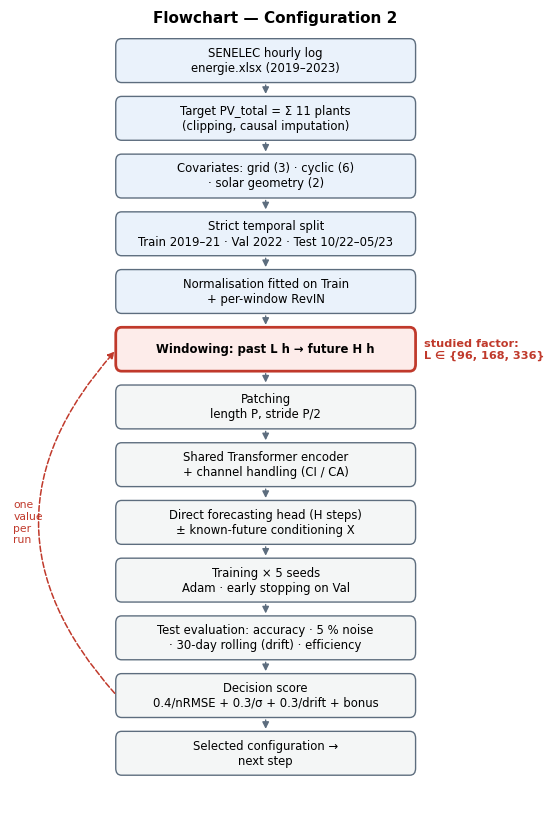

In [2]:
fc.draw(2, "Flowchart — Configuration 2", "flow_config2")

## 2. Configurations evaluated

In [3]:
ds = m.build_dataset()
configs = configs_for(2)
pd.DataFrame([dict(name=c.name(), P=c.P, L=c.L, H=c.H, channels=c.channel_mode, known_future=c.known_future,
                   physical_gate=c.physical_gate, n_patches=c.n_patches) for c in configs])

,name,P,L,H,channels,known_future,physical_gate,n_patches
0,PatchTST-CAX_P12_L96_H24,12,96,24,CA,True,False,15
1,PatchTST-CAX_P12_L168_H24,12,168,24,CA,True,False,27
2,PatchTST-CAX_P12_L336_H24,12,336,24,CA,True,False,55


## 3. Training and evaluation (5 seeds each)

In [4]:
results = [m.evaluate_configuration(c, ds) for c in configs]   # reads the cache if it exists
detail = pd.DataFrame([dict(configuration=r["name"], **{k: g[k] for k in
         ["seed", "epochs", "duration_s", "RMSE", "MAE", "nRMSE", "R2", "noise_degradation", "drift_7d", "drift_D30_D1"]})
         for r in results for g in r["per_seed"]])
detail

,configuration,seed,epochs,duration_s,RMSE,MAE,nRMSE,R2,noise_degradation,drift_7d,drift_D30_D1
0,PatchTST-CAX_P12_L96_H24,0,20,411.5315,9.2898,5.4720,0.2099,0.9723,0.0053,0.5671,0.5360
1,PatchTST-CAX_P12_L96_H24,1,25,519.7785,9.3623,5.6208,0.2115,0.9719,0.0061,0.5645,0.5833
2,PatchTST-CAX_P12_L96_H24,2,25,520.6915,9.3196,5.3055,0.2106,0.9721,0.0038,0.6050,0.5124
3,PatchTST-CAX_P12_L96_H24,3,25,532.1567,9.1702,5.1682,0.2072,0.9730,0.0041,0.5710,0.4714
4,PatchTST-CAX_P12_L96_H24,4,25,532.5672,9.3249,5.2219,0.2107,0.9721,0.0046,0.5947,0.5031
5,PatchTST-CAX_P12_L168_H24,0,17,610.0148,9.1267,5.5268,0.2062,0.9733,0.0043,0.6037,0.5437
6,PatchTST-CAX_P12_L168_H24,1,25,877.0354,9.0266,5.2093,0.2039,0.9738,0.0047,0.5992,0.6601
7,PatchTST-CAX_P12_L168_H24,2,23,791.8121,9.0612,5.2093,0.2047,0.9736,0.0037,0.5825,0.5446
8,PatchTST-CAX_P12_L168_H24,3,25,855.0012,9.0015,5.1526,0.2034,0.9740,0.0049,0.5480,0.5791
9,PatchTST-CAX_P12_L168_H24,4,25,871.2810,8.8632,4.9452,0.2002,0.9748,0.0041,0.5864,0.5486


## 4. Comparison table of the metrics (mean over 5 seeds) and naive baselines

In [5]:
table = m.comparison_table(results)
_, true0, orig0 = an.load_predictions(results[0]["name"])
refs = an.baseline_rows(ds, orig0, true0, configs[0].H) if len({c.H for c in configs}) == 1 else None
columns = ["configuration", "RMSE", "RMSE_std", "MAE", "nRMSE", "nRMSE_day", "R2", "MBE", "noise_degradation",
           "drift_D30_D1", "drift_7d", "inference_ms", "size_MB", "n_parameters", "score", "normalised_score", "rejected_noise"]
shown = pd.concat([table[columns], refs], ignore_index=True) if refs is not None else table[columns]
m.TABLES_DIR.mkdir(exist_ok=True)
shown.to_csv(m.TABLES_DIR / "table_config2.csv", index=False)
shown.round(4)

,configuration,RMSE,RMSE_std,MAE,nRMSE,nRMSE_day,R2,MBE,noise_degradation,drift_D30_D1,drift_7d,inference_ms,size_MB,n_parameters,score,normalised_score,rejected_noise
0,PatchTST-CAX_P12_L96_H24,9.2934,0.0735,5.3577,0.2100,0.2230,0.9723,-0.3692,0.0048,0.5212,0.5805,2.5106,0.5595,142849.0,6.7021,0.5679,False
1,PatchTST-CAX_P12_L168_H24,9.0158,0.0974,5.2086,0.2037,0.2146,0.9739,-0.0050,0.0044,0.5752,0.5839,2.9255,0.7265,186625.0,5.7561,0.7009,False
2,PatchTST-CAX_P12_L336_H24,9.4942,0.1459,5.5612,0.2145,0.2282,0.9711,0.1996,0.0031,0.6652,0.6218,4.7074,1.1161,288769.0,4.6034,0.1000,False
3,Persistence D-1,10.3923,0.0000,4.9667,0.2348,NaN,0.9653,0.0030,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,7-day mean,10.8215,0.0000,5.3064,0.2445,NaN,0.9624,-0.0260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


*Reading the columns.* `RMSE_std`: standard deviation over the 5 seeds (robustness). `nRMSE_day`: nRMSE restricted to
daytime hours. `noise_degradation`: relative RMSE increase under 5 % noise on the exogenous channels. `drift_D30_D1`: raw
ratio of `projet.md` (sensitive to the cloudiness of two isolated days); `drift_7d`: smoothed ratio used in the score.
`score`: raw formula of `projet.md`; `normalised_score`: each criterion mapped to [0, 1] across the compared variants.

In [6]:
dm = an.dm_tests(ds, results)
dm.round(4)

,configuration,reference,skill_score,DM,p_value
0,PatchTST-CAX_P12_L96_H24,persistence,0.1032,-2.4597,0.0139
1,PatchTST-CAX_P12_L96_H24,7-day mean,0.1388,-2.5526,0.0107
2,PatchTST-CAX_P12_L168_H24,persistence,0.1314,-2.9661,0.0030
3,PatchTST-CAX_P12_L168_H24,7-day mean,0.1659,-3.0762,0.0021
4,PatchTST-CAX_P12_L336_H24,persistence,0.0902,-1.9623,0.0498
5,PatchTST-CAX_P12_L336_H24,7-day mean,0.1263,-2.4155,0.0157


## 5. Seed rosary and 30-day stability

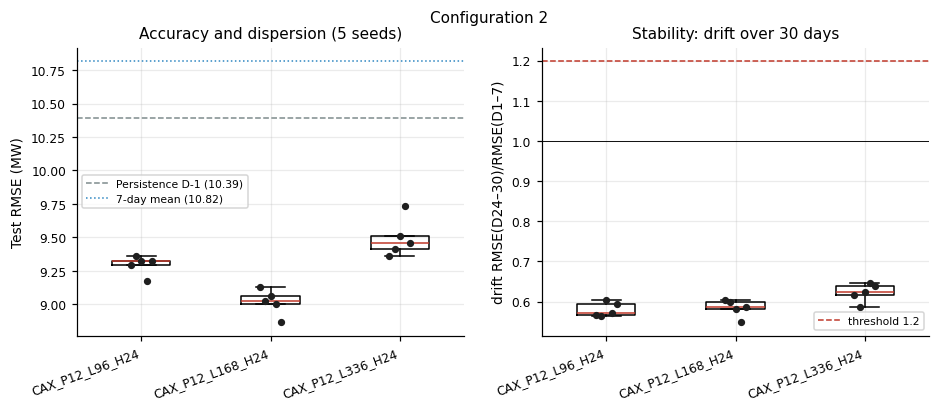

In [7]:
an.fig_rosary(results, ds, "fig_config2_rosary", "Configuration 2")

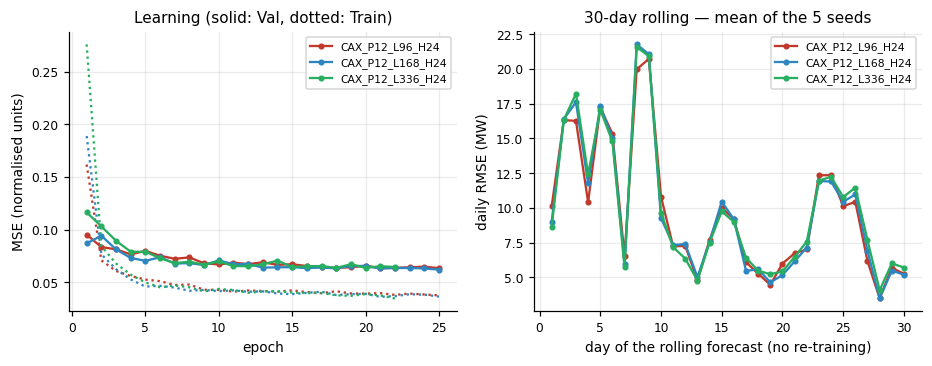

In [8]:
an.fig_learning_and_drift(results, "fig_config2_learning_drift")

## 6. Observed vs predicted series — best model of the configuration

Selected configuration: PatchTST-CAX_P12_L168_H24


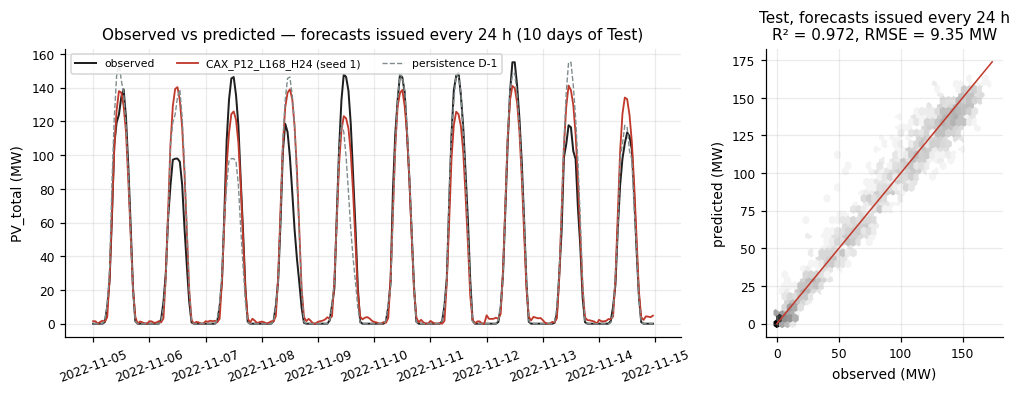

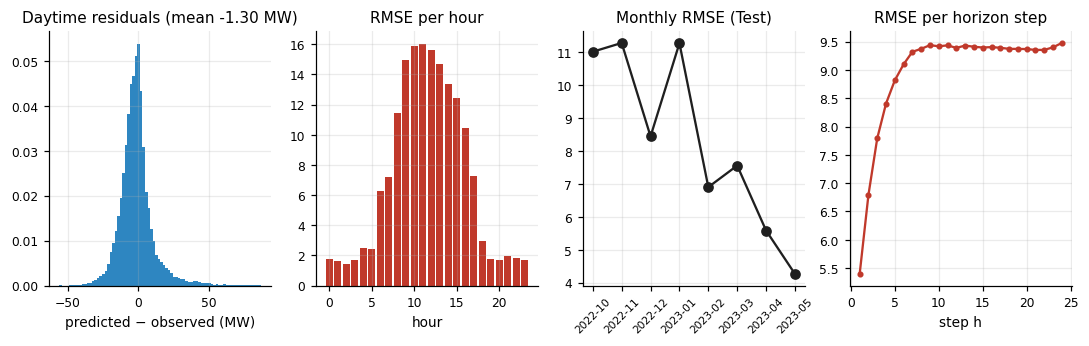

In [9]:
selected = an.selected_at("config2_history")
print("Selected configuration:", selected)
res_selected = [r for r in results if r["name"] == selected][0]
an.fig_observed_vs_predicted(res_selected, ds, "fig_config2_observed_predicted")
an.fig_residuals(res_selected, ds, "fig_config2_residuals")

### Conclusion of configuration 2

**Selected configuration: `PatchTST-CAX_P12_L168_H24`** (normalised decision score = 0.701; raw score = 5.76).

- `PatchTST-CAX_P12_L96_H24`: RMSE = 9.29 ± 0.07 MW, nRMSE = 0.210, gain vs persistence = +10.6 %, degradation under noise = +0.5 %, 7-day drift = 0.58, inference = 2.5 ms, 142,849 parameters.
- `PatchTST-CAX_P12_L168_H24`: RMSE = 9.02 ± 0.10 MW, nRMSE = 0.204, gain vs persistence = +13.2 %, degradation under noise = +0.4 %, 7-day drift = 0.58, inference = 2.9 ms, 186,625 parameters.
- `PatchTST-CAX_P12_L336_H24`: RMSE = 9.49 ± 0.15 MW, nRMSE = 0.215, gain vs persistence = +8.6 %, degradation under noise = +0.3 %, 7-day drift = 0.62, inference = 4.7 ms, 288,769 parameters.

- RMSE gap between the best and the worst variant: 0.48 MW (5.3 %).
- All variants meet the robustness criterion (degradation < 15 %): yes; all meet the drift target < 1.2: yes; all meet the efficiency targets (< 100 ms, < 50 MB): yes.